In [1]:
import functions
import importlib
import matplotlib.pyplot as plt
import cv2
import numpy as np
importlib.reload(functions)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Concatenate

Total de imagens originais: 511
Total de labels: 511


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 510, 510, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1016064)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │   130,056,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,076,099 (496.20 MB)

 Trainable params: 130,076,099 (496.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 84s 7s/step - accuracy: 0.3636 - loss: 24.0210 - val_accuracy: 0.3636 - val_loss: 51.8632
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3295 - loss: 32.8411 - val_accuracy: 0.3182 - val_loss: 5.0398
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.4205 - loss: 3.7400 - val_accuracy: 0.3182 - val_loss: 2.2576
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7386 - loss: 0.6190 - val_accuracy: 0.3636 - val_loss: 1.9159
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.8636 - loss: 0.3756 - val_accuracy: 0.4091 - val_loss: 2.0018
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9545 - loss: 0.2354 - val_accuracy: 0.4091 - val_loss: 2.9212
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.8636 - loss: 0.2581 - val_accuracy: 0.4545 - val_loss: 2.5288
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9205 - loss: 0.2076 - val_accuracy: 0.5455 - val_loss: 2.3836
Epoch 9/20
3

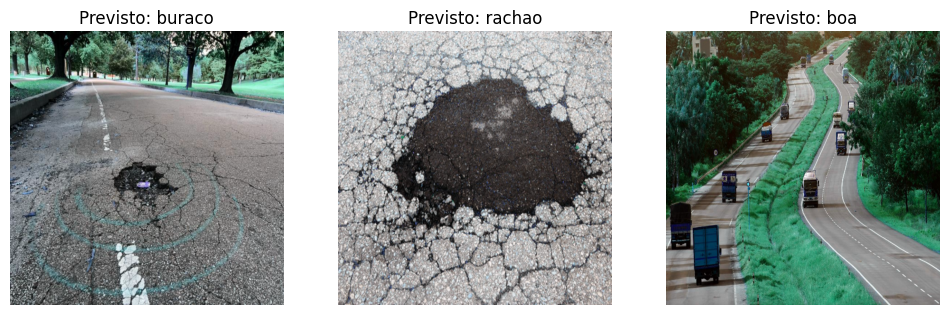

In [2]:
# Rede neural para prever buracos, rachões e boas usando apenas as imagens originais
# Carregar imagens e labels (sem máscaras, sem filtro)
imagens, labels = functions.load_original_images()

# Normalizar imagens
X_imgs = np.array(imagens) / 255.0

y = np.array(labels)

# --- Balanceamento das classes (undersampling) ---
classes = np.unique(y)
min_count = min([np.sum(y == c) for c in classes])

X_img_bal = []
y_bal = []
for c in classes:
    idx = np.where(y == c)[0]
    np.random.shuffle(idx)
    idx_cut = idx[:min_count]
    X_img_bal.append(X_imgs[idx_cut])
    y_bal.append(y[idx_cut])

X_imgs = np.concatenate(X_img_bal, axis=0)
y = np.concatenate(y_bal, axis=0)

# One-hot encoding dos labels
y_cat = to_categorical(y, num_classes=3)

# Divisão treino/val/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_imgs, y_cat, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=np.argmax(y_train, axis=1)
)

# Modelo CNN simples
input_img = Input(shape=(X_imgs.shape[1], X_imgs.shape[2], 3))
x = Conv2D(32, (3,3), activation='relu')(input_img)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model_simple = Model(inputs=input_img, outputs=output)
model_simple.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_simple.summary()

# Treinamento
history_simple = model_simple.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

# Avaliação
loss, acc = model_simple.evaluate(X_test, y_test)
print(f"Test Accuracy (imagens originais): {acc:.2f}")

# Visualização de previsões
class_names = ["buraco", "rachao", "boa"]
indices = []
for c in range(3):
    idxs = np.where(np.argmax(y_test, axis=1) == c)[0]
    idx = np.random.choice(idxs)
    indices.append(idx)

plt.figure(figsize=(12,4))
for i, idx in enumerate(indices):
    img = X_test[idx]
    pred = model_simple.predict(img[np.newaxis,...])
    pred_class = class_names[np.argmax(pred)]
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f"Previsto: {pred_class}")
    plt.axis('off')
plt.show()

In [3]:
loss, acc = model_simple.evaluate(X_test, y_test)
print(f"Test Accuracy (imagens originais): {acc:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.6071 - loss: 2.8572
Test Accuracy (imagens originais): 0.61
